In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Connect to ml directory
ml_root = Path().resolve().parents[0]
sys.path.append(str(ml_root))

# Load the dataset
data_path = ml_root / "data" / "processed" / "train_FD001_features.csv"
train_features = pd.read_csv(data_path)

print("=" * 60)
print("Dataset Loaded Successfully")
print(f"Shape: {train_features.shape}")

Dataset Loaded Successfully
Shape: (20631, 48)


In [2]:
feature_cols = [c for c in train_features.columns if c not in ["engine_id", "cycle", "RUL"]]

X = train_features[feature_cols]
y = train_features["RUL"]

# Split by Engine ID to prevent data leakage
engine_ids = train_features["engine_id"].unique()
train_ids, val_ids = train_test_split(engine_ids, test_size=0.20, random_state=42)

train_set = train_features[train_features["engine_id"].isin(train_ids)]
val_set = train_features[train_features["engine_id"].isin(val_ids)]

X_train = train_set[feature_cols]
y_train = train_set["RUL"]

X_val = val_set[feature_cols]
y_val = val_set["RUL"]

print("=" * 60)
print("Training Samples   :", X_train.shape)
print("Validation Samples :", X_val.shape)

Training Samples   : (16561, 45)
Validation Samples : (4070, 45)


In [4]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val) # NEVER fit on validation data!

# Train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_val_scaled)

print("=" * 60)
print("Linear Regression Training & Prediction Completed")

Linear Regression Training & Prediction Completed


BASELINE RESULTS
RMSE : 20.00
MAE  : 16.12
R²   : 0.7702


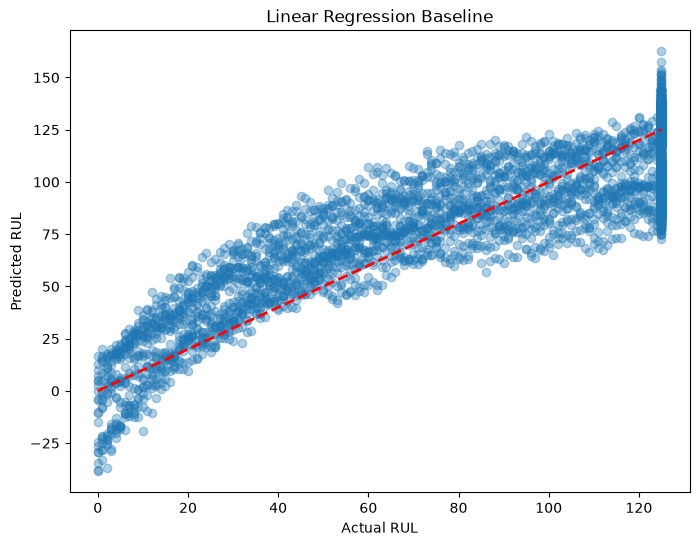

In [5]:
# Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print("=" * 60)
print("BASELINE RESULTS")
print("=" * 60)
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

# Visualize
docs_path = ml_root.parent / "docs"
docs_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,6))
plt.scatter(y_val, y_pred, alpha=0.35)
plt.plot([0,125], [0,125], color="red", linestyle="--", linewidth=2)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Linear Regression Baseline")

plot_path = docs_path / "lr_baseline_predictions.png"
plt.savefig(plot_path, bbox_inches="tight")
plt.show()

In [6]:
# Model Coefficients (Feature Importance for Linear Models)
importance = pd.DataFrame({"Feature": feature_cols, "Coefficient": model.coef_})
importance["Absolute"] = importance["Coefficient"].abs()
importance = importance.sort_values(by="Absolute", ascending=False)

print("=" * 60)
print("Top 10 Important Features")
display(importance.head(10))

# Save Predictions
prediction_path = ml_root / "artifacts"
prediction_path.mkdir(parents=True, exist_ok=True)

results = pd.DataFrame({"Actual_RUL": y_val.values, "Predicted_RUL": np.round(y_pred,2)})
results.to_csv(prediction_path / "linear_regression_predictions.csv", index=False)

print("=" * 60)
print("Predictions Saved Successfully to artifacts folder.")

Top 10 Important Features


,Feature,Coefficient,Absolute
27,sensor_9_rollmean,-6.456456,6.456456
35,sensor_14_rollmean,-6.090633,6.090633
25,sensor_8_rollmean,4.906633,4.906633
29,sensor_11_rollmean,-4.707877,4.707877
33,sensor_13_rollmean,4.285691,4.285691
12,sensor_14,3.981590,3.981590
23,sensor_7_rollmean,3.680949,3.680949
21,sensor_4_rollmean,-3.626313,3.626313
37,sensor_15_rollmean,-3.318157,3.318157
17,sensor_2_rollmean,-2.984450,2.984450


Predictions Saved Successfully to artifacts folder.
